# Lab 06 – Frame Extraction

**Objective**

Extract image frames from FaceForensics++ videos using OpenCV.

**Author**

Shreya

**Module**

Frame Extraction

In [1]:
# Clone repository

import os

os.chdir("/content")

!rm -rf Deepfake-Detection-KYC

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 101 (delta 47), reused 59 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 36.56 KiB | 959.00 KiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/Deepfake-Detection-KYC


In [2]:
from pathlib import Path

print(Path.cwd())

!ls

/content/Deepfake-Detection-KYC
data  environment.yml  outputs	      README.md  requirements.txt
docs  notebooks        presentations  reports	 src


In [3]:
!pip install -q kaggle pandas numpy matplotlib opencv-python tqdm

In [4]:
import os
from getpass import getpass

print("Configure Kaggle")

os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass("API Token: ")

print("Kaggle configured")

Configure Kaggle
Username: shreyamaurya07
API Token: ··········
Kaggle configured


In [5]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [6]:
!kaggle datasets list -s faceforensics


ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
greatgamedota/faceforensics                                      FaceForensics                                         724841395  2020-02-19 17:42:41.720000           4863         38  0.75             
xdxd003/ff-c23                                                   FaceForensics++ Dataset (C23)                       17891522096  2024-12-07 06:16:49.157000          51770        107  1                
hungle3401/faceforensics                                         FaceForensics++                                      2927395799  2024-02-13 04:35:27.907000           9020         26  0.3125  

In [7]:
!kaggle datasets download -d xdxd003/ff-c23

Dataset URL: https://www.kaggle.com/datasets/xdxd003/ff-c23
License(s): other
100% 16.7G/16.7G [13:15<00:00, 22.5MB/s]



In [8]:
!ls -lh

total 17G
drwxr-xr-x 6 root root 4.0K Jul 29 14:38 data
drwxr-xr-x 2 root root 4.0K Jul 29 14:38 docs
-rw-r--r-- 1 root root  206 Jul 29 14:38 environment.yml
-rw-r--r-- 1 root root  17G Dec  7  2024 ff-c23.zip
drwxr-xr-x 2 root root 4.0K Jul 29 14:38 notebooks
drwxr-xr-x 6 root root 4.0K Jul 29 14:38 outputs
drwxr-xr-x 2 root root 4.0K Jul 29 14:38 presentations
-rw-r--r-- 1 root root  960 Jul 29 14:38 README.md
drwxr-xr-x 2 root root 4.0K Jul 29 14:38 reports
-rw-r--r-- 1 root root    0 Jul 29 14:38 requirements.txt
drwxr-xr-x 8 root root 4.0K Jul 29 14:38 src


In [9]:
!mkdir -p data/raw

In [10]:
!unzip -q ff-c23.zip -d data/raw/

In [11]:
!find data/raw -maxdepth 2 -type d

data/raw
data/raw/FaceForensics++_C23
data/raw/FaceForensics++_C23/original
data/raw/FaceForensics++_C23/Deepfakes
data/raw/FaceForensics++_C23/FaceShifter
data/raw/FaceForensics++_C23/FaceSwap
data/raw/FaceForensics++_C23/Face2Face
data/raw/FaceForensics++_C23/csv
data/raw/FaceForensics++_C23/DeepFakeDetection
data/raw/FaceForensics++_C23/NeuralTextures


LAB 6

In [12]:
from pathlib import Path
from collections import Counter

dataset = Path("data/raw/FaceForensics++_C23")

extensions = Counter()

for file in dataset.rglob("*"):
    if file.is_file():
        extensions[file.suffix.lower()] += 1

print("File Types Found:")
for ext, count in sorted(extensions.items()):
    print(f"{ext}: {count}")

File Types Found:
.csv: 10
.mp4: 7000


In [14]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

In [15]:
# ==========================================================
# Dataset Paths
# ==========================================================

DATASET_PATH = Path("data/raw/FaceForensics++_C23")
OUTPUT_PATH = Path("outputs/extracted_frames")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_PATH)
print("Output :", OUTPUT_PATH)

Dataset: data/raw/FaceForensics++_C23
Output : outputs/extracted_frames


In [16]:
# ==========================================================
# Find One Sample Video
# ==========================================================

video_files = list(DATASET_PATH.rglob("*.mp4"))

print("Total Videos:", len(video_files))

sample_video = video_files[0]

print("Sample Video:")
print(sample_video)

Total Videos: 7000
Sample Video:
data/raw/FaceForensics++_C23/original/896.mp4


In [17]:
# ==========================================================
# Open Sample Video
# ==========================================================

import cv2

cap = cv2.VideoCapture(str(sample_video))

print("Video Opened:", cap.isOpened())

Video Opened: True


In [18]:
# ==========================================================
# Video Properties
# ==========================================================

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps if fps > 0 else 0

print(f"Frame Count : {frame_count}")
print(f"FPS         : {fps}")
print(f"Resolution  : {width} x {height}")
print(f"Duration    : {duration:.2f} seconds")

Frame Count : 531
FPS         : 25.0
Resolution  : 640 x 480
Duration    : 21.24 seconds


In [19]:
# ==========================================================
# Read First Frame
# ==========================================================

success, frame = cap.read()

print("Frame Read:", success)

if success:
    print("Frame Shape:", frame.shape)

Frame Read: True
Frame Shape: (480, 640, 3)


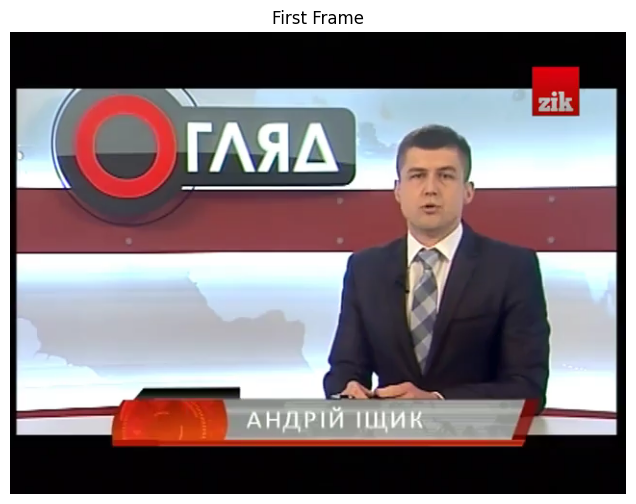

In [20]:
# ==========================================================
# Display First Frame
# ==========================================================

import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.title("First Frame")
plt.axis("off")
plt.show()

In [21]:
# ==========================================================
# Extract Every 10th Frame
# ==========================================================

cap = cv2.VideoCapture(str(sample_video))

FRAME_INTERVAL = 10

frame_number = 0
saved_count = 0

while True:

    success, frame = cap.read()

    if not success:
        break

    if frame_number % FRAME_INTERVAL == 0:

        filename = OUTPUT_PATH / f"frame_{saved_count:04d}.jpg"

        cv2.imwrite(str(filename), frame)

        saved_count += 1

    frame_number += 1

cap.release()

print("=================================")
print("Extraction Complete")
print("=================================")
print(f"Total Frames Read : {frame_number}")
print(f"Frames Saved      : {saved_count}")
print(f"Frame Interval    : {FRAME_INTERVAL}")

Extraction Complete
Total Frames Read : 531
Frames Saved      : 54
Frame Interval    : 10


In [22]:
# ==========================================================
# Verify Extracted Frames
# ==========================================================

saved_frames = sorted(OUTPUT_PATH.glob("*.jpg"))

print(f"Total Saved Frames: {len(saved_frames)}")

print("\nFirst 5 Frames:")

for frame in saved_frames[:5]:
    print(frame.name)

Total Saved Frames: 54

First 5 Frames:
frame_0000.jpg
frame_0001.jpg
frame_0002.jpg
frame_0003.jpg
frame_0004.jpg


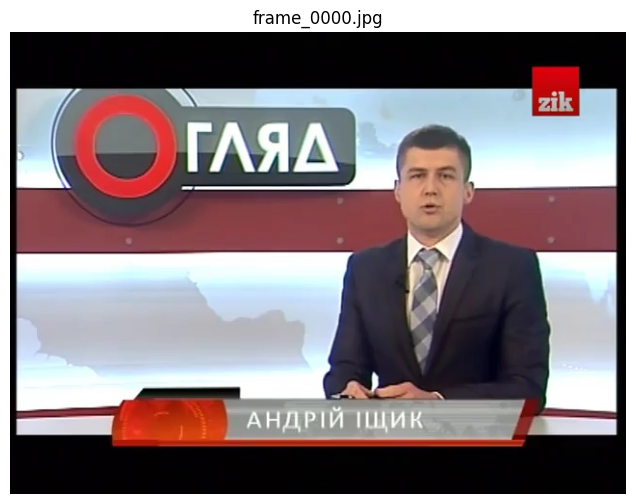

In [23]:
# ==========================================================
# Display One Saved Frame
# ==========================================================

image = cv2.imread(str(saved_frames[0]))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.title(saved_frames[0].name)
plt.axis("off")
plt.show()

In [26]:
!git pull origin main

remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 14 (delta 8), reused 11 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (14/14), 1.09 MiB | 3.76 MiB/s, done.
From https://github.com/Aishwarya-93/Deepfake-Detection-KYC
 * branch            main       -> FETCH_HEAD
   a425c26..7c4dcce  main       -> origin/main
Updating a425c26..7c4dcce
Fast-forward
 notebooks/Lab_05_Video_Loading.ipynb | 1218 ++++++++++++++++++++++++++++++++++
 src/preprocessing/frame_extractor.py |   96 +++
 src/preprocessing/video_loader.py    |  107 +++
 3 files changed, 1421 insertions(+)
 create mode 100644 notebooks/Lab_05_Video_Loading.ipynb
 create mode 100644 src/preprocessing/frame_extractor.py
 create mode 100644 src/preprocessing/video_loader.py


In [27]:
!find src -type f

src/models/.gitkeep
src/training/.gitkeep
src/preprocessing/frame_extractor.py
src/preprocessing/.gitkeep
src/preprocessing/inspect_dataset.py
src/preprocessing/video_loader.py
src/preprocessing/read_metadata.py
src/preprocessing/validate_metadata.py
src/utils/.gitkeep
src/dataset/.gitkeep
src/evaluation/.gitkeep


In [30]:
from src.preprocessing.frame_extractor import (
    get_video_info,
    extract_frames
)

In [31]:
sample_video = list(DATASET_PATH.rglob("*.mp4"))[0]

info = get_video_info(sample_video)
print(info)

{'frame_count': 531, 'fps': 25.0, 'width': 640, 'height': 480}


In [32]:
result = extract_frames(
    sample_video,
    OUTPUT_PATH,
    interval=10
)

print(result)

{'frames_read': 531, 'frames_saved': 54, 'interval': 10}
